#Diagrama de relaciones "Farmacia"

Esquema del Diagrama de Relaciones de la Base de Datos para Farmacia y la posterior implementación del sistema en las operaciones del negocio.



Diagrama de relaciones "FARMACIA"

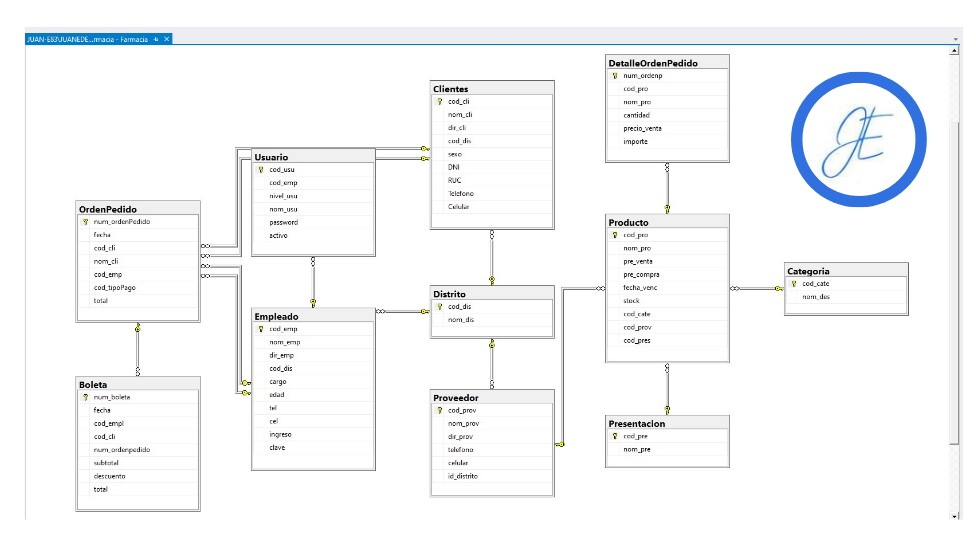

--Designer: Juan Eder Bohórquez Aguilar

--Diseño de BD "Farmacia"

--CREACION BD
CREATE DATABASE Farmacia
--USO DE LA BD
USE Farmacia

--CREACION DE TABLAS

CREATE TABLE Usuario
(
cod_usu varchar(8)primary key not null,
cod_emp varchar(8)not null,
nivel_usu varchar(2)not null,
nom_usu varchar(30)not null,
password varchar(10) not null,
activo varchar(2) not null
)
GO

CREATE TABLE Clientes
(
cod_cli varchar(8) primary key not null,
nom_cli varchar(40)not null,
dir_cli varchar(40) null,
cod_dis varchar(8)null,
sexo varchar(1)not null,
DNI INT NULL,
RUC int null,
Telefono int null,
Celular int null
)
go

CREATE TABLE OrdenPedido
(
num_ordenPedido varchar(8) primary key not null,
fecha datetime not null,
cod_cli varchar (8) null,
nom_cli varchar(40)null,
cod_emp varchar(8) null,
cod_tipoPago varchar(8) null,
total int null
)
go


CREATE TABLE Distrito
(
cod_dis varchar(8)primary key not null,
nom_dis varchar(40) not null
)
go


CREATE TABLE Categoria
(
cod_cate varchar(8)primary key not null,
nom_des varchar(40)not null
)
go


CREATE TABLE Producto
(
cod_pro varchar(8)primary key not null,
nom_pro varchar(40)not null,
pre_venta decimal(10,2) not null,
pre_compra decimal(10,2) not null,
fecha_venc datetime not null,
stock int not null,
cod_cate varchar(8)not null,
cod_prov varchar(8)null,
cod_pres varchar(8)null
)
go


CREATE TABLE Empleado
(
cod_emp varchar(8)primary key not null,
nom_emp varchar(40)not null,
dir_emp varchar(40)null,
cod_dis varchar(8)not null,
cargo varchar(40) not null,
edad varchar(2)null,
tel int not null,
cel int null,
ingreso datetime not null,
clave varchar (20) not null,
)
go


CREATE TABLE DetalleOrdenPedido
(
num_ordenp varchar(8)primary key not null,
cod_pro varchar(8) not null,
nom_pro varchar(40) not null,
cantidad decimal(10,2)null,
precio_venta decimal(10,2),
importe decimal(10,2)
)
GO


CREATE TABLE Boleta
(
num_boleta varchar(8) primary key not null,
fecha datetime not null,
cod_empl varchar(8) not null,
cod_cli varchar(8)not null,
num_ordenpedido varchar(8)not null,
subtotal int not null,
descuento int null,
total int not null
)
go


CREATE TABLE Presentacion
(
cod_pre varchar(8)primary key not null,
nom_pre varchar(50)null,
)
go


CREATE TABLE Proveedor
(
cod_prov varchar(8)primary key not null,
nom_prov varchar(40)not null,
dir_prov varchar(50)null,
telefono char(7)null,
celular char(10)null,
id_distrito varchar(8)null
)
go

-- UNION Y RESTRICCIONES CLAVES SECUNDARIAS

  alter table ordenpedido
  add constraint pk_cod_cli foreign key(cod_cli) references clientes(cod_cli)

  alter table clientes
  add constraint pk_cod_dis_cli foreign key (cod_dis) references distrito(cod_dis) -- no funciona nose por que

  alter table producto
  add constraint pk_cod_cate foreign key(cod_cate) references categoria(cod_cate)
  
  alter table empleado
  add constraint pk_cod_dis foreign key (cod_dis) references distrito(cod_dis)
  
  alter table ordenpedido
  add constraint pk_cod_enpL foreign key (cod_emp) references empleado(cod_emp)
  
  alter table ordenpedido
  add constraint pk_cod_clis foreign key(cod_cli) references clientes(cod_cli)
  
  alter table detalleordenPedido
  add constraint pk_cod_pro foreign key (cod_pro) references producto(cod_pro)
  
  alter table boleta
  add constraint pk_or_pedi foreign key (num_ordenpedido) references ordenpedido(num_ordenpedido)
  
  alter table ordenpedido
  add constraint pk_cod_empl foreign key (cod_emp) references empleado(cod_emp)
  
  alter table producto
  add constraint pk_cod_prove foreign key(cod_prov) references proveedor(cod_prov)
  
  alter table producto
  add constraint pk_cod_presentacion foreign key(cod_pres) references presentacion(cod_pre)
  
  alter table usuario
  add constraint pk_cod_emple foreign key(cod_emp) references empleado(cod_emp)
  
  alter table proveedor
  add constraint pk_cod_dis_pro foreign key(id_distrito) references distrito(cod_dis)

  alter table clientes
  add constraint uni_dni unique(dni)

  alter table clientes
  add constraint CK_SEXO CHECK(SEXO IN('M','F'))

--RESTRICCIONES VALIDACION DE CAMPOS
  alter table distrito add constraint uni_distrito unique(nom_dis)  
  alter table clientes add constraint CK_DNI CHECK(LEN(dni)=8)